In [1]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

In [3]:
df_vendas = pd.read_csv('01.amazon_sales_dataset.csv')
df_vendas.columns

Index(['order_id', 'order_date', 'ship_date', 'delivery_date', 'order_status',
       'customer_id', 'customer_name', 'country', 'state', 'city',
       'product_id', 'product_name', 'category', 'sub_category', 'brand',
       'quantity', 'unit_price', 'discount', 'shipping_cost', 'total_sales',
       'payment_method'],
      dtype='str')

In [4]:
df_vendas.dtypes

order_id              str
order_date            str
ship_date             str
delivery_date         str
order_status          str
customer_id           str
customer_name         str
country               str
state                 str
city                  str
product_id            str
product_name          str
category              str
sub_category          str
brand                 str
quantity            int64
unit_price        float64
discount          float64
shipping_cost     float64
total_sales       float64
payment_method        str
dtype: object

In [5]:
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        10000 non-null  str    
 1   order_date      10000 non-null  str    
 2   ship_date       10000 non-null  str    
 3   delivery_date   10000 non-null  str    
 4   order_status    10000 non-null  str    
 5   customer_id     10000 non-null  str    
 6   customer_name   10000 non-null  str    
 7   country         10000 non-null  str    
 8   state           10000 non-null  str    
 9   city            10000 non-null  str    
 10  product_id      10000 non-null  str    
 11  product_name    10000 non-null  str    
 12  category        10000 non-null  str    
 13  sub_category    10000 non-null  str    
 14  brand           10000 non-null  str    
 15  quantity        10000 non-null  int64  
 16  unit_price      10000 non-null  float64
 17  discount        10000 non-null  float64
 18

In [6]:
coluna_alvo = 'total_sales'

# Medidas de Tendencia Centrais
total_vendas = df_vendas[coluna_alvo].sum()
media_valor_vendas = df_vendas[coluna_alvo].mean()
venda_minima = df_vendas[coluna_alvo].min()
venda_maxima = df_vendas[coluna_alvo].max()

In [7]:
# Medidas de Posição
q1 = np.percentile(df_vendas[coluna_alvo], 25)
# q2 = Mediana
q2 = np.percentile(df_vendas[coluna_alvo], 50)
q3 = np.percentile(df_vendas[coluna_alvo], 75)

In [8]:
# avaliar a 'confiabilidade' da média
delta_media_mediana = media_valor_vendas - q2
distancia_percentual = media_valor_vendas/q2
# Caso 1. Distancia <= 10% (0.9 ~ 1.1)
# R = Média é altamente confiavel
# Caso 2. Distancia entre 10% e 25% 
# (0.75~0.9 / 1.10~1.25)
# R = Média sofre influencia moderada de extremos
# Caso 3. Distancia > 25% (< 0.75 / > 1.25)
# R = NÃO confie na média, ela é distorcida 
# pelos extremos


In [9]:
# Medidas de Dispersão

# 1. Amplitude
amplitude = venda_maxima - venda_minima

# 2. Variancia e Desvio Padrão
# Medem a distancia média dos pontos até a Média
# Se for um valor alto -> Maior volatilidade
variancia = df_vendas[coluna_alvo].var()
desvio_padrao = df_vendas[coluna_alvo].std()

# 3.IQR -> 50% 'internos' dos dados (25%~75%)
# Muito robusto a ouliers
iqr = q3 - q1

# 4. Coeficiente de Variação (CV)
# Muito usado para comparar volatilidades 
# de 'grandezas' diferentes (colunas diferentes)
# Obs.: Multiplicado por 100 para ser descrito como porcentagem
cv = (desvio_padrao/media_valor_vendas)*100

In [10]:
# Assimetria (Skewness)
assimetria = df_vendas[coluna_alvo].skew()

# Caso 1. Assimetria entre -0.5 e 0.5
# R = Dados Equilibrados
# Caso 2. Assimetria > 0.5 (Positiva)
# R = Valores altos são raros, porém são tão
# grandes que distorcem o calculo
# Caso 3. Assimetria < - 0.5 (Negativa)
# R = Menos valores distorcem o calculo para baixo

# Kurtosis (curtose)
# Mede o 'peso' das caudas -> 
# frequencia e gravidade dos outliers
curtose = df_vendas[coluna_alvo].kurtosis()

In [11]:
print('\n--- Resumo Executivo de Vendas ---')
print(f'1. Volume Total (Soma das Vendas): \
      $ {total_vendas:,.2f}')
# Representa o tamanho total da nossa operação no periodo
print(f'2. Gasto Médio: $ {media_valor_vendas:,.2f}')
# Valor esperado que um cliente gaste em média conosco
print(f'3. Maior Venda: $ {venda_maxima:,.2f}')
# Nosso recorde. Investigar o perfil do cliente
print(f'4. Menor Venda: $ {venda_minima:,.2f}')
# Menor valor registrado. Investigar se há anomalias ou fraude



--- Resumo Executivo de Vendas ---
1. Volume Total (Soma das Vendas):       $ 642,129,105.55
2. Gasto Médio: $ 64,212.91
3. Maior Venda: $ 249,155.53
4. Menor Venda: $ 309.94


In [12]:
print('--- Relatorio Estatísticos de Negócio ---')

print(f'A média de vendas é \
      $ {media_valor_vendas:,.2f}')
print(f'A mediana (valor central) das vendas é \
      $ {q2:,.2f}')
print(f'O Delta (Diferença Financeira) entre \
      elas é: $ {delta_media_mediana:,.2f}')

print('\n--- Analise Comportamental ---\n')
print(f'Distância Relativa entre elas: \
      {distancia_percentual:.2f}')


if abs(distancia_percentual-1) < 0.10:
      print(f'INFERÊNCIA: Baixa Dispersão. \
            A média é confiável para representar a coluna.')

elif abs(distancia_percentual-1) < 0.25:
      print(f'INFERÊNCIA: Dispersão Moderada. \
            Fique atento aos extremos, média começa a mentir.')
      
else:
      print(f'INFERÊNCIA: Alta Dispersão. \
            A média NÃO é confiável, foque na mediana.')

print(f'Grau de Assimetria (Skewness): \
      {assimetria:.4f}')

if assimetria > 0.5:
    print(f'INFERÊNCIA (Assimetria Positiva): \
            Nossas vendas tem uma cauda longa para a direita.\
            Os grandes clientes são minoria, todavia eles \
            faturam valores expressivos \
            puxando a venda média para cima')
elif assimetria < -0.5:
    print(f'INFERÊNCIA (Assimetria Negativa): \
            Nossa vendas tem uma cauda longa para a esquerda.\
            O valor médio está sendo puxado para baixo por um \
            grande volume de vendas baratas, \
            talvez pela liquidação')
else:
    print(f'INFERÊNCIA (Simétrica): Distribuição Equilibrada.\
          Média e mediana estão bem próximas.')


--- Relatorio Estatísticos de Negócio ---
A média de vendas é       $ 64,212.91
A mediana (valor central) das vendas é       $ 50,287.18
O Delta (Diferença Financeira) entre       elas é: $ 13,925.73

--- Analise Comportamental ---

Distância Relativa entre elas:       1.28
INFERÊNCIA: Alta Dispersão.             A média NÃO é confiável, foque na mediana.
Grau de Assimetria (Skewness):       0.9635
INFERÊNCIA (Assimetria Positiva):             Nossas vendas tem uma cauda longa para a direita.            Os grandes clientes são minoria, todavia eles             faturam valores expressivos             puxando a venda média para cima


In [13]:
print(f'--- Dispersão ---')
print(f'Amplitude Total: $ {amplitude:.2f}')
# Amplitude no negócio: Diferença entre a maior e menor venda
print(f'Desvio Padrão: $ {desvio_padrao:.2f}')
# Desvio no negócio: Nível de dispersão dos valores de venda
print(f'Coeficiente de Variação: {cv:.2f}%')
if cv > 30:
    print('INFERÊNCIA: Volatilidade Alta.\
          Não há consistencia no faturamento diario')
else:
    print('INFERÊNCIA: Volatidade Baixa.\
          Vendas são consistentes e prevísiveis.')

print(f'Intervalo Interquartil (IQR): ${iqr:,.2f}')
print('INFERÊNCIA: Esta é a variação de gastos do nosso' \
'consumidor padrão, ignorando clientes que compram muito pouco' \
'ou valores muito altos')

# Curtose -> Curva Normal (Curtose = 3)
# Curtose no Pandas -> Já trata do Excesso sobre a curva normal
# No Pandas .kurtosis() = 0 -> Mesocúrtica
print(f'Curtose (Excesso - Fisher): {curtose:.4f}')
if curtose > 0.5:
    print('INFERÊNCIA: Distribuição Leptocúrtica' \
    '(Pico agudo, caudas grossas)')
    print('Sobre o negócio: A maioria das vendas estão no ' \
    'centro, todavia temos uma altissima probabilidade' \
    'de eventos extremos (outliers)')
elif curtose < -0.5:
    print(f'INFERÊNCIA: Distribuição Platicúrtica \
          (Pico suave (achatado), caudas finas)')
    print('Sobre o negócio: AS vendas estão muito bem ' \
    'distribuidas, chance baixa de ter ' \
    'eventos extremos (outliers)')
else:
    print(f'INFERÊNCIA: Distribuição Mesocúrtica \
          (picos medianos, caudas normal)')
    print('Sobre negócio: Comportamento Normal e' \
    'totalmente previsível')



--- Dispersão ---
Amplitude Total: $ 248845.59
Desvio Padrão: $ 50992.64
Coeficiente de Variação: 79.41%
INFERÊNCIA: Volatilidade Alta.          Não há consistencia no faturamento diario
Intervalo Interquartil (IQR): $69,380.70
INFERÊNCIA: Esta é a variação de gastos do nossoconsumidor padrão, ignorando clientes que compram muito poucoou valores muito altos
Curtose (Excesso - Fisher): 0.2736
INFERÊNCIA: Distribuição Mesocúrtica           (picos medianos, caudas normal)
Sobre negócio: Comportamento Normal etotalmente previsível


In [14]:
# Navegação e Filtros Avançados

# iloc -> pega 'n' linhas -> indice
amostra = df_vendas.iloc[0:10]
amostra

,order_id,order_date,ship_date,delivery_date,order_status,customer_id,customer_name,country,state,city,...,product_name,category,sub_category,brand,quantity,unit_price,discount,shipping_cost,total_sales,payment_method
0,A10000,2026-01-31,2026-01-31,2026-01-08,Delivered,C5691,Ricky Potter,India,South Carolina,New Joe,...,without,Home,Furniture,Doyle-Jordan,3,42467.79,0.26,60.85,94339.3438,Card
1,A10001,2026-01-20,2026-02-03,2026-02-03,Delivered,C9811,Chris Davenport,India,Tennessee,Madisonmouth,...,school,Home,Furniture,Davis LLC,2,36138.76,0.24,112.96,55043.8752,COD
2,A10002,2026-01-15,2026-02-07,2026-01-03,Delivered,C7341,Timothy Gallagher,India,Iowa,East Larryberg,...,I,Electronics,Laptop,Watson and Sons,4,47148.93,0.14,64.11,162256.4292,UPI
3,A10003,2026-01-18,2026-01-15,2026-01-20,Delivered,C4012,Angela Collins,India,Kentucky,South Margaretshire,...,step,Electronics,Laptop,"Sandoval, Buckley and Solis",1,18487.99,0.06,114.15,17492.8606,Card
4,A10004,2026-01-27,2026-01-04,2026-01-23,Delivered,C1328,David Davidson DDS,India,North Dakota,Velasquezview,...,bit,Home,Kitchen,"Key, Bautista and Bowen",1,1742.25,0.10,40.47,1608.4950,UPI
5,A10005,2026-01-05,2026-01-12,2026-01-11,Delivered,C9019,Lauren Russell,India,South Carolina,Ryanburgh,...,through,Home,Furniture,Lee Inc,3,12618.95,0.22,105.47,29633.8130,Card
6,A10006,2026-01-04,2026-01-10,2026-01-21,Delivered,C9866,Heather Campos,India,Colorado,Turnerville,...,page,Electronics,Mobile,Wade-Jackson,4,41577.60,0.06,29.90,156361.6760,COD
7,A10007,2026-02-07,2026-02-01,2026-01-10,Delivered,C2638,Elizabeth Thornton,India,Georgia,Ricemouth,...,choice,Home,Furniture,Johns-Kelly,4,21118.07,0.19,61.18,68483.7268,COD
8,A10008,2026-02-09,2026-02-03,2026-01-01,Delivered,C4823,Theresa Collins,India,Maryland,Coreystad,...,like,Electronics,Mobile,"Silva, White and Bates",5,12891.02,0.03,99.08,62620.5270,COD
9,A10009,2026-01-24,2026-01-26,2026-02-10,Delivered,C9948,Chelsea Brown,India,South Carolina,Kendraton,...,example,Fashion,Clothing,"Carroll, Barnes and Harris",2,42438.49,0.12,144.57,74836.3124,UPI


In [15]:
# loc -> usa o nome da coluna e filtra com base em algo

# Quem são os melhores clientes?
clientes_vip = df_vendas.loc[df_vendas['total_sales'] > q3]
clientes_vip

clientes_vip2 = df_vendas.loc[df_vendas['total_sales'] > q3,
    ['order_id', 'customer_name', 'category', 'total_sales']]
clientes_vip2

,order_id,customer_name,category,total_sales
0,A10000,Ricky Potter,Home,94339.3438
2,A10002,Timothy Gallagher,Electronics,162256.4292
6,A10006,Heather Campos,Electronics,156361.6760
15,A10015,Dakota Henderson,Home,158829.3820
16,A10016,Thomas Thompson,Home,93585.5060
...,...,...,...,...
9971,A19971,Tina King,Electronics,176074.8640
9981,A19981,Christopher Nelson,Home,159902.4785
9986,A19986,Kevin Ward,Home,128262.2410
9990,A19990,Allison Anderson,Electronics,116039.3520


In [16]:
# query (consulta)

# O gerente quer saber quais pedidos da categoria Eletronico
# ficaram acima da média geral
filtro = \
f"category == 'Electronics' and total_sales > {media_valor_vendas}"
eletronicos = df_vendas.query(filtro)
eletronicos

,order_id,order_date,ship_date,delivery_date,order_status,customer_id,customer_name,country,state,city,...,product_name,category,sub_category,brand,quantity,unit_price,discount,shipping_cost,total_sales,payment_method
2,A10002,2026-01-15,2026-02-07,2026-01-03,Delivered,C7341,Timothy Gallagher,India,Iowa,East Larryberg,...,I,Electronics,Laptop,Watson and Sons,4,47148.93,0.14,64.11,162256.4292,UPI
6,A10006,2026-01-04,2026-01-10,2026-01-21,Delivered,C9866,Heather Campos,India,Colorado,Turnerville,...,page,Electronics,Mobile,Wade-Jackson,4,41577.60,0.06,29.90,156361.6760,COD
10,A10010,2026-01-27,2026-01-03,2026-01-24,Delivered,C9288,Jamie Gamble,India,Montana,Shieldston,...,alone,Electronics,Mobile,"Robinson, Baxter and Alexander",3,29556.04,0.27,42.02,64769.7476,COD
19,A10019,2026-02-04,2026-01-13,2026-02-08,Delivered,C5064,Phyllis Farrell,India,Kansas,West Blakemouth,...,ground,Electronics,Laptop,"Hammond, Freeman and Young",4,19917.19,0.02,124.85,78200.2348,COD
30,A10030,2026-01-16,2026-01-21,2026-02-10,Delivered,C7260,Scott Johnson,India,Pennsylvania,North Sara,...,recognize,Electronics,Accessories,Shaw Group,4,46779.63,0.06,125.58,176016.9888,NetBanking
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9943,A19943,2026-01-04,2026-01-04,2026-01-17,Delivered,C1110,Corey Kim,India,Rhode Island,Davisborough,...,listen,Electronics,Laptop,Sanders Ltd,4,26685.41,0.03,66.11,103605.5008,UPI
9951,A19951,2026-01-03,2026-02-06,2026-01-09,Delivered,C2183,Dana Garcia,India,Iowa,Lake Donaldshire,...,anyone,Electronics,Accessories,"Murphy, Estes and Jackson",3,43084.85,0.28,132.16,93195.4360,COD
9971,A19971,2026-01-01,2026-01-19,2026-01-27,Delivered,C3066,Tina King,India,Delaware,New Williamfurt,...,require,Electronics,Accessories,Hall-Martin,5,41904.82,0.16,74.62,176074.8640,UPI
9977,A19977,2026-01-15,2026-02-01,2026-01-26,Delivered,C3430,Charles Wilson,India,Missouri,New Lisahaven,...,even,Electronics,Laptop,"Green, Sanchez and Smith",3,30770.25,0.20,73.76,73922.3600,Card


In [ ]:
# df_vendas é a base 
# agrupar por qual coluna? category
# o que iremos calcular? total_sales

df_categoria_agrupada = \
df_vendas.groupby('category') ['total_sales'].sum(). reset_index()
df_categoria_ordenada = df_categoria_agrupada.sort_values(by='total_sales', ascending=False)

df_categoria_ordenada



,category,total_sales
0,Electronics,2.193563e+08
2,Home,2.147638e+08
1,Fashion,2.080091e+08


In [19]:
%pip install matplotlib
import matplotlib.pyplot as plt

                                              0.0/8.1 MB ? eta -:--:--
     --                                       0.5/8.1 MB 13.8 MB/s eta 0:00:01
     ----                                     0.9/8.1 MB 13.7 MB/s eta 0:00:01
     ------                                   1.3/8.1 MB 13.6 MB/s eta 0:00:01
     --------                                 1.8/8.1 MB 12.9 MB/s eta 0:00:01
     -----------                              2.4/8.1 MB 11.9 MB/s eta 0:00:01
     --------------                           3.0/8.1 MB 12.0 MB/s eta 0:00:01
     -----------------                        3.6/8.1 MB 12.7 MB/s eta 0:00:01
     --------------------                     4.2/8.1 MB 12.1 MB/s eta 0:00:01
     ----------------------                   4.6/8.1 MB 11.8 MB/s eta 0:00:01
     -------------------------                5.1/8.1 MB 12.1 MB/s eta 0:00:01
     ---------------------------              5.7/8.1 MB 12.1 MB/s eta 0:00:01
     ------------------------------           6.2/8.1 MB 11.


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<BarContainer object of 3 artists>

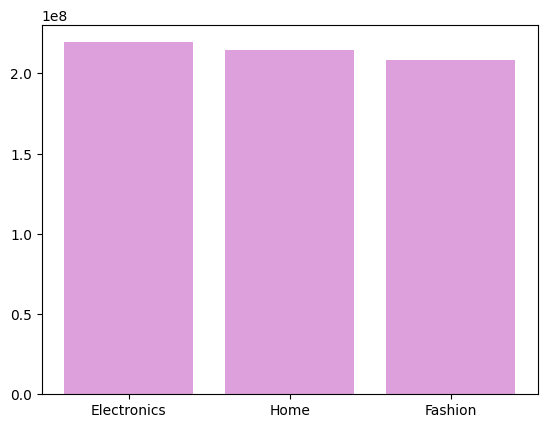

In [23]:
plt.bar(df_categoria_ordenada['category'], df_categoria_ordenada['total_sales'], color = 'plum' \
'')